# Phase 5 — Model Interpretation

## Feature Importance Analysis

After training and selecting the best-performing model in Phase 4, the next step is to understand how the model makes predictions.

Machine learning models, especially ensemble models like Random Forest, can sometimes behave like black boxes. Feature importance analysis helps reveal which variables contribute the most to the model’s predictions.

Understanding feature importance allows us to identify the key factors that influence student dropout risk. These insights can be valuable for educational institutions seeking to identify at-risk students early and provide appropriate support.

In this phase, we will extract feature importance scores from the trained Random Forest model and analyze which features most strongly influence dropout prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [7]:
import shap

In [2]:
# Load the trained model
best_model = joblib.load("../models/best_model.pkl")

In [3]:
# Load the training data used during model training
X_train = pd.read_csv("../data/processed/X_train_smote.csv")

In [4]:
# Extract feature importance scores
feature_importances = best_model.feature_importances_

In [5]:
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.186181
24,Curricular units 1st sem (approved),0.103807
31,Curricular units 2nd sem (grade),0.085977
25,Curricular units 1st sem (grade),0.062041
16,Tuition fees up to date,0.050210
19,Age at enrollment,0.042102
29,Curricular units 2nd sem (evaluations),0.033712
1,Application mode,0.029846
3,Course,0.029321
12,Admission grade,0.028967


## Visualizing Feature Importance

To better understand which variables influence the model's predictions the most, we visualize the top 15 most important features identified by the Random Forest model.

Feature importance measures how much each feature contributes to reducing prediction error across the trees in the Random Forest.

Features with higher importance scores have a stronger influence on the model’s ability to predict student dropout.

/var/folders/t9/s0jfggbn5p92nttbdsz2n9vc0000gn/T/ipykernel_47465/1442238938.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


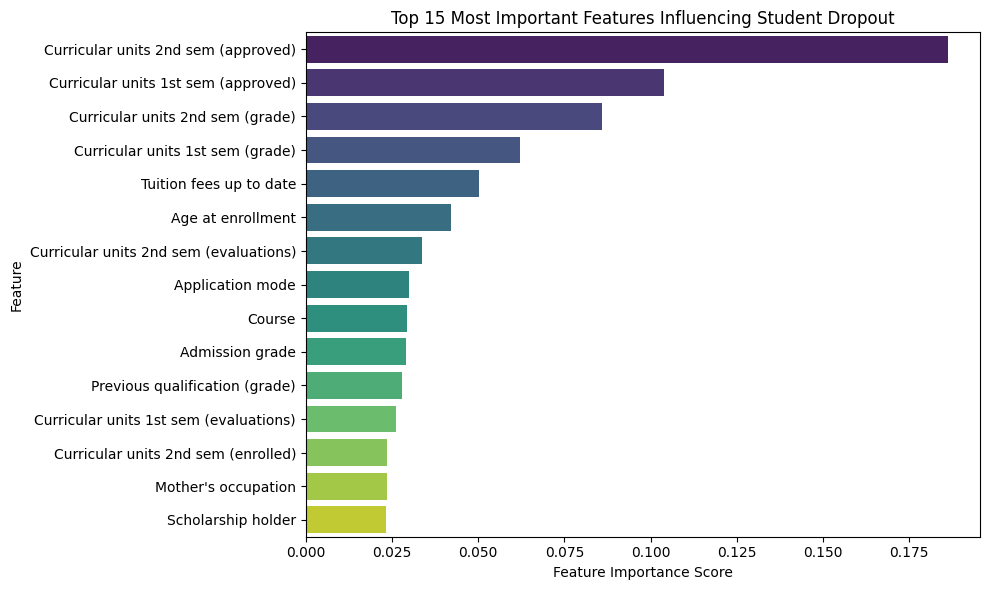

In [6]:
# Select top 15 most important features
top_features = importance_df.head(15)

# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features Influencing Student Dropout")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Interpreting the Model Insights

The feature importance analysis reveals several key factors that strongly influence the model's ability to predict student dropout.

### 1. Academic Performance is the Strongest Predictor

The most influential features are related to students’ academic progress, particularly:

- Curricular units 2nd semester (approved)
- Curricular units 1st semester (approved)
- Curricular units 2nd semester (grade)
- Curricular units 1st semester (grade)

These variables indicate how many courses a student has successfully completed and the grades obtained. Students who struggle academically or fail to complete courses are significantly more likely to drop out. This aligns with expectations, as academic difficulty is often a primary driver of student attrition.

### 2. Financial Stability Also Plays a Role

The feature **"Tuition fees up to date"** appears among the most important predictors. This suggests that students experiencing financial difficulties may face a higher risk of dropping out, likely due to challenges in continuing their education.

### 3. Age at Enrollment Has Moderate Influence

The feature **"Age at enrollment"** indicates that student age may influence persistence. Older students might face additional responsibilities such as employment or family commitments, which can affect their ability to continue their studies.

### 4. Admission and Background Factors Contribute

Features such as:

- Admission grade
- Previous qualification grade
- Application mode

also contribute to the prediction. These variables reflect the student’s academic background and preparation prior to entering the institution.

### Overall Insight

The model suggests that **academic progress and course completion are the most critical indicators of student dropout risk**, followed by financial stability and certain demographic factors.

These insights could help educational institutions identify at-risk students early and design targeted interventions such as academic support programs or financial assistance.

## Deeper Model Explainability Using SHAP

While feature importance provides a general overview of which variables influence the model the most, it does not show how individual features contribute to specific predictions.

To gain deeper insight into the model’s behavior, we use **SHAP (SHapley Additive exPlanations)**. SHAP is a model interpretability technique based on cooperative game theory that explains how each feature contributes to a prediction.

SHAP provides two important perspectives:

**Global Explainability**
- Shows which features influence the model most overall.
- Helps confirm patterns observed in feature importance analysis.

**Local Explainability**
- Explains individual predictions by showing how each feature increases or decreases the probability of dropout.

Using SHAP helps ensure the model is transparent and allows us to better understand the factors driving student dropout predictions.

In [8]:
# Create SHAP explainer for the trained Random Forest model
explainer = shap.TreeExplainer(best_model)

In [9]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_train)

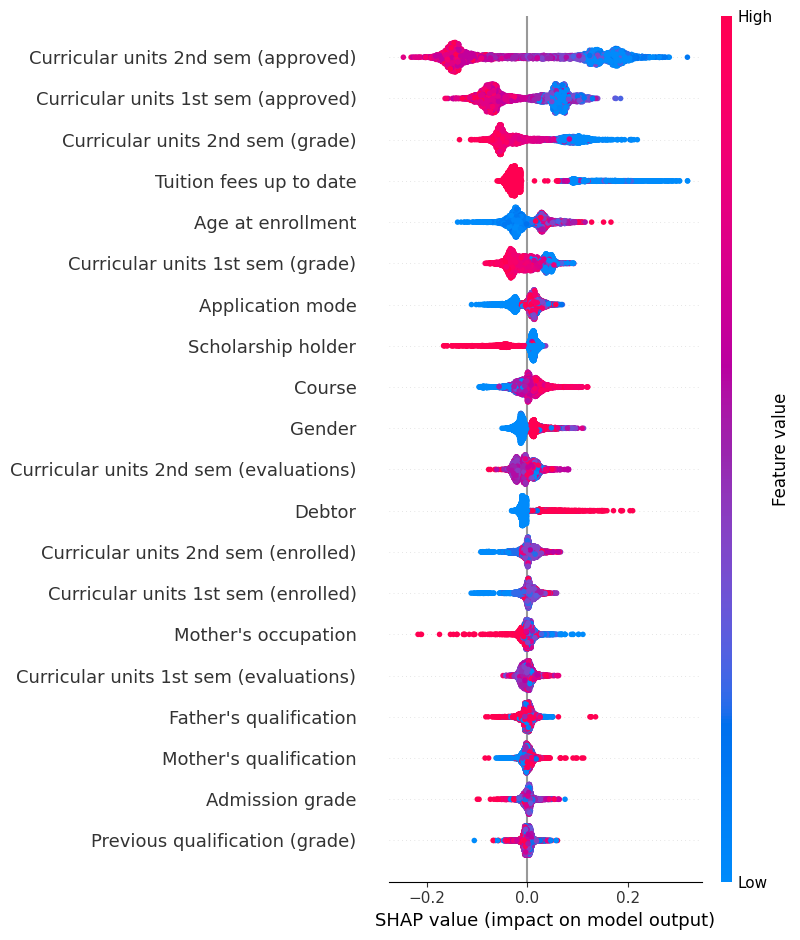

In [13]:
# SHAP summary plot for the dropout class
shap.summary_plot(shap_values[:, :, 1], X_train)

## SHAP Explainability Insights

The SHAP summary plot provides a deeper explanation of how each feature influences the model’s predictions.

The features at the top of the chart have the greatest overall impact on predicting student dropout.

### Academic Performance Dominates

The most influential variables are related to academic progress, including:

- Curricular units 2nd semester (approved)
- Curricular units 1st semester (approved)
- Curricular units 2nd semester (grade)
- Curricular units 1st semester (grade)

Students who successfully complete and perform well in courses are significantly less likely to drop out. Conversely, students with fewer approved courses or lower grades are more likely to leave the program.

### Financial Factors Influence Dropout

The feature **"Tuition fees up to date"** also shows a strong impact. Students who are behind on tuition payments appear to have a higher probability of dropping out.

### Demographic and Background Variables

Other variables such as **age at enrollment, admission grade, and application mode** contribute moderately to the prediction. These factors may reflect differences in preparation, life circumstances, or academic readiness.

### Overall Insight

Both the feature importance analysis and SHAP explainability confirm that **academic performance and course completion are the strongest indicators of student persistence**, followed by financial stability and certain demographic characteristics.

## Phase 5 Summary

In this phase, we focused on understanding **how the trained machine learning model makes predictions**.

After selecting the Random Forest model in Phase 4, we analyzed which features have the greatest influence on predicting student dropout.

### Feature Importance Analysis

Using the Random Forest model, we extracted feature importance scores and visualized the **top 15 most influential variables**.  
The results show that **academic performance is the strongest predictor of student dropout**.

Features related to course completion and grades, such as:

- Curricular units 2nd semester (approved)
- Curricular units 1st semester (approved)
- Curricular units 2nd semester (grade)
- Curricular units 1st semester (grade)

have the greatest impact on the model's predictions.

### Financial and Background Factors

Other important variables include:

- Tuition fees up to date
- Age at enrollment
- Admission grade
- Application mode

These features suggest that financial stability and prior academic preparation also influence whether a student continues their studies.

### SHAP Explainability

To gain deeper insight into the model’s behavior, SHAP (SHapley Additive exPlanations) was used.

SHAP helps explain **how each feature contributes to individual predictions**, allowing us to understand whether a feature increases or decreases the probability of dropout.

The SHAP analysis confirmed the findings from the feature importance chart:  
**academic performance and course completion are the most critical indicators of student persistence**.

### Key Insight

The model suggests that students who struggle academically or fail to complete courses are significantly more likely to drop out. Financial challenges and certain background factors also contribute to dropout risk.

These insights could help educational institutions identify at-risk students earlier and provide targeted support such as academic assistance or financial guidance.